<a href="https://colab.research.google.com/github/MaryamAmjad2/PyTorch/blob/main/Advance%20PyTorch/04_Custom_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn


# Device Agnostic Code

In [ ]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

# Downloading Custom Dataset

For tutoril puposes the instructor shorten the dataset so we are downloading it from their github repo

Our dataset has
3 classes
75 training and 25 testing images


In [ ]:
# Get Data
import requests
import zipfile
from pathlib import Path

# Setup path to a data folder
data_path=Path('Data/')
image_path=data_path/"pizza_steak_sushi"

if image_path.is_dir():
  print("Exist")
else:
  print("Doesnt Exist")
  image_path.mkdir(parents=True,
                  exist_ok=True )

# Download Pizza Steak Sushi Data
with open (data_path/"pizza_steak_sushi.zip",'wb') as f:
  request=requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
  print("Download Started")
  f.write(request.content)

# UnZip it
with zipfile.ZipFile(data_path/'pizza_steak_sushi.zip','r') as zip_ref:
  print("Unzipping File")
  zip_ref.extractall(image_path)
  print("DONE")


Doesnt Exist
Download Started
Unzipping File
DONE


# Visualize

In [ ]:
import os
def walk_through_dir(dir_path):
  """ Walks through dir Path and return content"""
  for dirpath,dirnames,filenames in os.walk(dir_path):
    print(f" There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")
walk_through_dir(image_path)


 There are 2 directories and 0 images in Data/pizza_steak_sushi
 There are 3 directories and 0 images in Data/pizza_steak_sushi/test
 There are 0 directories and 31 images in Data/pizza_steak_sushi/test/sushi
 There are 0 directories and 19 images in Data/pizza_steak_sushi/test/steak
 There are 0 directories and 25 images in Data/pizza_steak_sushi/test/pizza
 There are 3 directories and 0 images in Data/pizza_steak_sushi/train
 There are 0 directories and 72 images in Data/pizza_steak_sushi/train/sushi
 There are 0 directories and 75 images in Data/pizza_steak_sushi/train/steak
 There are 0 directories and 78 images in Data/pizza_steak_sushi/train/pizza


In [ ]:
train_dir=image_path/"train"
test_dir=image_path/'test'

Image Class : pizza
Image Height : 384
Image Width : 512


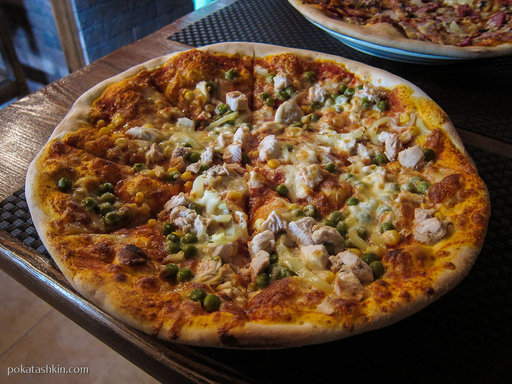

In [ ]:
import random
from PIL import Image
random.seed(42)

# Get all image Path
image_path_list = list(image_path.glob("*/*/*.jpg"))


# Pick a random image
random_image_path=random.choice(image_path_list)
random_image_path

# Get Image Class
image_class=random_image_path.parent.stem
image_class


# Open Image with PIL
img=Image.open(random_image_path)

# Print Metadata
print(f"Image Class : {image_class}")
print(f'Image Height : {img.height}')
print(f'Image Width : {img.width}')
img


Glob()=
Get all image paths matching the pattern "*/*/*.jpg" (i.e. all .jpg files two folders deep)

.stem = Get the class name (folder name) from the parent directory, e.g. "pizza"

## Visualizng with Matplotlib

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

(np.float64(-0.5), np.float64(511.5), np.float64(383.5), np.float64(-0.5))

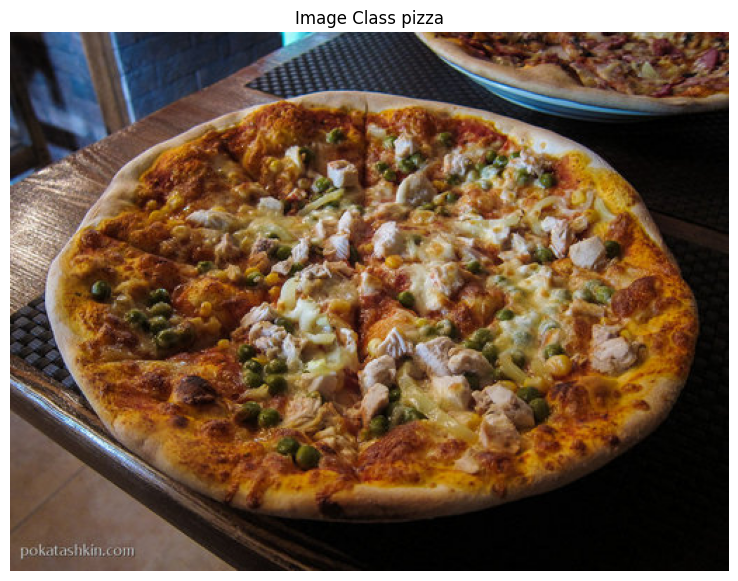

In [ ]:
# Turn Image into Array
image_as_array=np.asarray(img)

#Plot
plt.figure(figsize=(10,7))
plt.imshow(image_as_array)
plt.title(f"Image Class {image_class}")
plt.axis(False)


# Transforming Data

## Turning Images to Tensors

In [ ]:
from torch.utils.data import DataLoader
from torchvision  import datasets, transforms

In [ ]:
data_transform = transforms.Compose([

    # Resize images to 64X64
    transforms.Resize(size=(64,64)),

    # Flip the Image
    transforms.RandomHorizontalFlip(p=0.5),

    # Turn Image to Torch Tensor
    transforms.ToTensor()

])

In [ ]:
data_transform(img).dtype

torch.float32

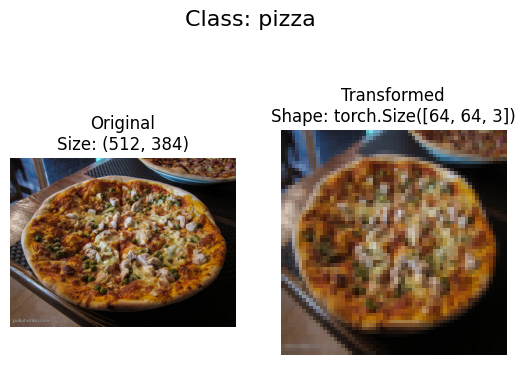

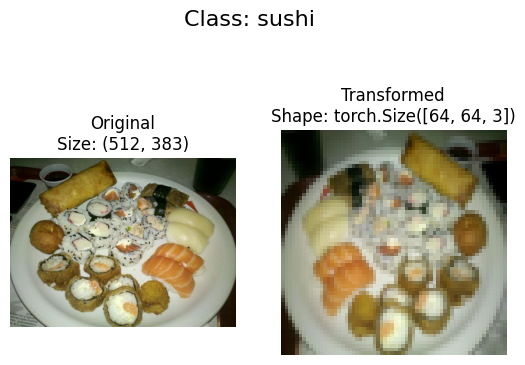

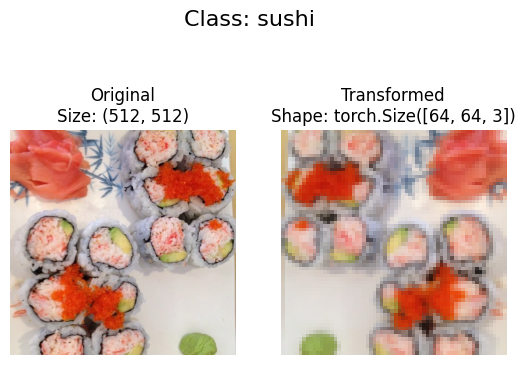

In [ ]:
import random

def plot_transformed_images(image_paths, transform, n=3, seed=42):
    '''Plotting transformed images'''

    random.seed(seed)
    rand_img_path = random.sample(image_paths, k=n)
    for image_path in rand_img_path:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(1, 2)
            ax[0].imshow(f)
            ax[0].set_title(f'Original\nSize: {f.size}')
            ax[0].axis(False)

            # Transform and plot
            transformed_image = transform(f).permute(1, 2, 0)  # (C, H, W) -> (H, W, C) for matplotlib
            ax[1].imshow(transformed_image)
            ax[1].set_title(f'Transformed\nShape: {transformed_image.shape}')
            ax[1].axis(False)

            fig.suptitle(f'Class: {image_path.parent.stem}', fontsize=16)

plot_transformed_images(image_path_list, data_transform)

# Loading All Images and Turning them into Tesnor

## Option 1: Loading with ImageFolder

In [ ]:
from torchvision import datasets
train_data=datasets.ImageFolder(root=train_dir,
                                transform=data_transform, #Transform data
                                target_transform=None) #Transform Targets/Label

test_data=datasets.ImageFolder(root=test_dir,
                               transform=data_transform
                               )
train_data

Dataset ImageFolder
    Number of datapoints: 225
    Root location: Data/pizza_steak_sushi/train
    StandardTransform
Transform: Compose(
               Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
               RandomHorizontalFlip(p=0.5)
               ToTensor()
           )

In [ ]:
class_names=train_data.classes
print(class_names)

#Get Class names as dict
class_dict=train_data.class_to_idx
print(class_dict)

len(train_data),len(test_data)

['pizza', 'steak', 'sushi']
{'pizza': 0, 'steak': 1, 'sushi': 2}


(225, 75)

In [ ]:
train_data.samples[1]

('Data/pizza_steak_sushi/train/pizza/1033251.jpg', 0)

In [ ]:
# Index on train data to get single image and label
train_data[0]
img=train_data[0][0]
label=train_data[0][1]
print(f"IMAGE------\n",img)
print(f'Image Shape :',img.shape)
print(f'Image datatype is:',img.dtype)
print("Label", label)
print("Image Class is :",class_names[label])


IMAGE------
 tensor([[[0.1137, 0.1020, 0.0980,  ..., 0.1255, 0.1216, 0.1176],
         [0.1059, 0.0980, 0.0980,  ..., 0.1294, 0.1294, 0.1294],
         [0.1020, 0.0980, 0.0941,  ..., 0.1333, 0.1333, 0.1333],
         ...,
         [0.1098, 0.1098, 0.1255,  ..., 0.1686, 0.1647, 0.1686],
         [0.0902, 0.0941, 0.1098,  ..., 0.1686, 0.1647, 0.1686],
         [0.0863, 0.0863, 0.0980,  ..., 0.1686, 0.1647, 0.1647]],

        [[0.0745, 0.0706, 0.0745,  ..., 0.0588, 0.0588, 0.0588],
         [0.0745, 0.0706, 0.0745,  ..., 0.0627, 0.0627, 0.0627],
         [0.0706, 0.0745, 0.0745,  ..., 0.0706, 0.0706, 0.0706],
         ...,
         [0.1255, 0.1333, 0.1373,  ..., 0.2510, 0.2392, 0.2392],
         [0.1098, 0.1176, 0.1255,  ..., 0.2510, 0.2392, 0.2314],
         [0.1020, 0.1059, 0.1137,  ..., 0.2431, 0.2353, 0.2275]],

        [[0.0941, 0.0902, 0.0902,  ..., 0.0157, 0.0196, 0.0196],
         [0.0902, 0.0863, 0.0902,  ..., 0.0196, 0.0157, 0.0196],
         [0.0902, 0.0902, 0.0902,  ..., 0.015

# DataLoader

In [ ]:
# Rearrange the order dimensions

img_permute=img.permute(1,2,0)
img_permute.shape

# Print out diff shapess
print("Orginal Shape: ",img.shape)
print("Image Permute Shape:", img_permute.shape)


Orginal Shape:  torch.Size([3, 64, 64])
Image Permute Shape: torch.Size([64, 64, 3])


In [ ]:
os.cpu_count()  # COUNT CPU CORES

2

In [ ]:
BATCH_SIZE=32

train_dataloader=DataLoader(batch_size = BATCH_SIZE,
                            shuffle=True,
                            dataset=train_data,
                            num_workers=os.cpu_count(),
                          )

test_dataloader=DataLoader(batch_size = BATCH_SIZE,
                            shuffle=False,
                            dataset=test_data,
                            num_workers=os.cpu_count(),
                          )

train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x798dd448e660>,
 <torch.utils.data.dataloader.DataLoader at 0x798dd42a5e50>)

In [ ]:
len(train_dataloader)

8

In [ ]:
img,label=next(iter(train_dataloader))
img.shape

torch.Size([32, 3, 64, 64])

## Option: 2 Creating a  Custom Dataset class in PyTorch

In [ ]:
type(class_names)

list

In [ ]:
import os
import pathlib
from PIL import Image
from torch.utils.data import Dataset
from torchvision import  transforms
from typing import Tuple,Dict,List   #just lets you label what type of data a function returns

In [ ]:
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

# Helper Function



*   Load Images from a File
*   Get Classes from Dataset


*   Get Classes a Dictionary from the dataset





In [ ]:
# Setup Path for target directory
target_directory=train_dir
print("Target Directory: ",target_directory)

#Get Class Names
class_names_found= sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_found




Target Directory:  Data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [ ]:
def find_classes(directory:str)->Tuple[List[str],Dict[str,int]]:
  '''Find Class Folder Name in a Directory'''

  # 1. Get Class Names from Scanning Target Director
  classes=sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  # Get Class Dic
  if not classes:
    raise FileNotFoundError("No Classes in Directory",{directory})
  else:
    class_to_idx={class_name : i for i,class_name in enumerate(classes)}

  return classes, class_to_idx


ImageFolder Does the same we just build Custom One For our Undersstanding

# Create Custom dataset to Replicate  ImageFolder



1.   Subclass torch.utils.data.dataset
2.   Init our subclass with target directory

1.   Create several atributes

  *   paths
  *   transform

  *   classes
  *   class to idx
4. Create a  Function to Load Images


1.   Overwrite the ____len___() method
2.   Overwrite the __getitem__()











In [ ]:
import torch
# Write a Custom dataset class

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
  #2. Initialize
  def __init__(self,targ_dir:str,transform=None):

    #3. Create Attributes

    # Get all Image Path
    self.paths=list(pathlib.Path(targ_dir).glob("*/*.jpg"))

    # Transform
    self.transform = transform

    # Create Classes and Class to idx
    self.classes, self.class_to_idx= find_classes(targ_dir)


  #4. Create a Function to Load Images

  def load_image(self,index:int)->Image.Image:
    ''' OPen an Image from a Path and return it'''
    image_path=self.paths[index]
    return Image.open(image_path)

  # 5. Overwrite the __len__()
  def __len__(self)->int:
    ''' Return How many samples we have'''
    return len(self.paths)

  #6. Overwrite the __getitem__()
  '''Return a particular sample'''
  def __getitem__(self,index:int)->Tuple[torch.Tensor,int]:
    img=self.load_image(index)
    class_name=self.paths[index].parent.name
    class_idx=self.class_to_idx[class_name]

    # Transform if neccesary
    if self.transform:
      return self.transform(img),class_idx
    else:
      return img,class_idx  #Untransformed

# Compare Our Custom data to  ImageFolder

In [ ]:
# Create a transform
train_transforms=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()

])

test_transforms=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()

])

In [ ]:
train_data_custom=ImageFolderCustom(train_dir,
                                    transform=train_transforms)
test_data_custom=ImageFolderCustom(test_dir,
                                   transform=test_transforms
                                   )

In [ ]:
train_data_custom, test_data_custom
print(len(train_data))
print(len(train_data_custom))

225
225


In [ ]:
train_data_custom.classes, train_data_custom.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

In [ ]:
# Check for Equality
print(train_data_custom.classes ==train_data.classes)
print(train_data_custom.class_to_idx == train_data.class_to_idx)

True
True


# Visualize Random Images from Our Custom dataset

In [ ]:
# Function to Display Random Images
def display_random_images(dataset:torch.utils.data.Dataset,
                          classes:List[str]=None,
                          n:int=10,
                          display_shape:bool=True,
                          seed:int=None
                          ):
  # Adjjust Display if n>10
  if n>10:
    n=10
    display_shape=False
    print("Only 10 Images Allowed")
  # Set the Random Seed
  if seed:
    random.seed(seed)

  # get Random Samples Index
  random_samples_idx=random.sample(range(len(dataset)),k=n)

  # Setup Plot
  plt.figure(figsize=(20,10))

  # Loop through the random samples and plot them with matplotlin
  for i, targ_sample in enumerate(random_samples_idx):
    targ_img,targ_label= dataset[targ_sample][0],dataset[targ_sample][1]

    # Adjust tensor dimension for plotting
    targ_img_adjust=targ_img.permute(1,2,0)

    # Plot

    plt.subplot(1,n,i+1)
    plt.imshow(targ_img_adjust)
    plt.axis(False)
    if classes:
      title=f"Class: {classes[targ_label]}"
      if display_shape:
        title=title+ f"\n Shape {targ_img_adjust.shape}"
      plt.title(title)





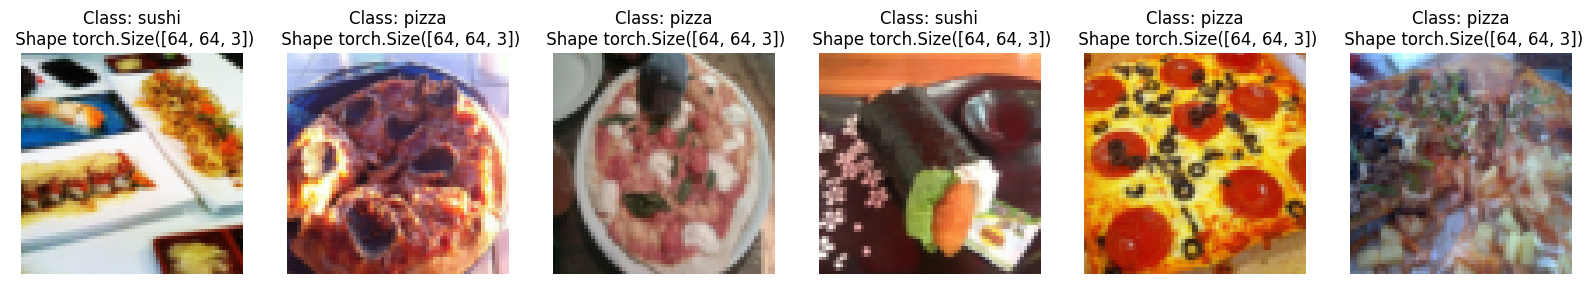

In [ ]:
# Display Random Images

display_random_images(train_data,class_names,6,True,42)

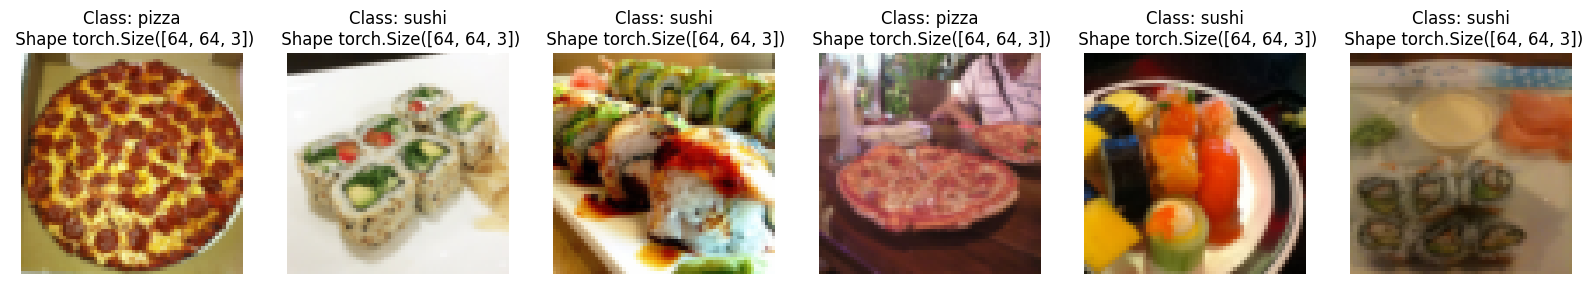

In [ ]:
display_random_images(train_data_custom,class_names,6,True,42)

#Turning Our Custom Dataset in DataLoader

In [ ]:
BATCH_SIZE=32

train_dataloader_custom=DataLoader(batch_size = BATCH_SIZE,
                            shuffle=True,
                            dataset=train_data_custom,
                            num_workers=os.cpu_count(),
                          )

test_dataloader_custom=DataLoader(batch_size = BATCH_SIZE,
                            shuffle=False,
                            dataset=test_data_custom,
                            num_workers=os.cpu_count(),
                          )

train_dataloader_custom,test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x798da2560b90>,
 <torch.utils.data.dataloader.DataLoader at 0x798dd42f62c0>)

In [ ]:
# Get Image and Label from custom dataloader
img_custom,label_custom=next(iter(train_dataloader_custom))
img_custom.shape

torch.Size([32, 3, 64, 64])

# Data Augmentation

Data augmentation is the practice of creating modified copies of your training images (rotated, flipped, zoomed, cropped, etc.) so your model sees more variety without needing to collect more real data.

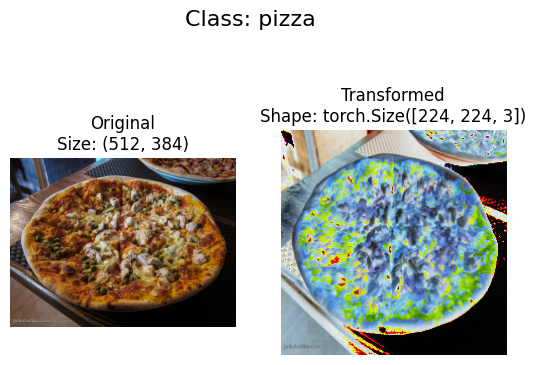

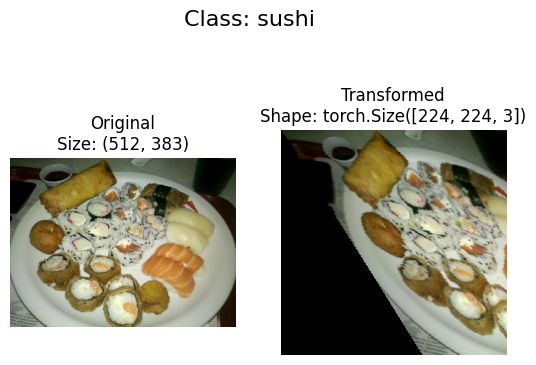

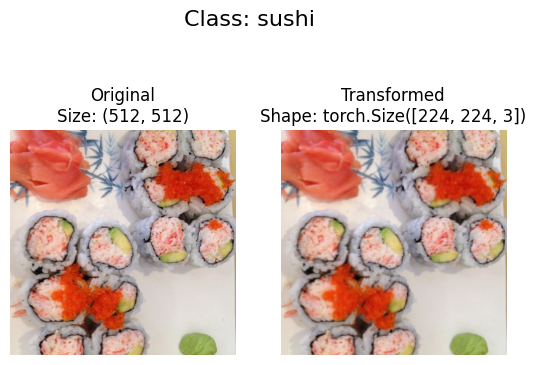

In [ ]:
# Trivial Augment

from torchvision import transforms
train_transform=transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31), #Between 0-31
    transforms.ToTensor()

])


test_transform=transforms.Compose([
    transforms.Resize(size=(224,224)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31), #Between 0-31
    transforms.ToTensor()

])

plot_transformed_images(image_path_list, train_transform,3,42)


# Building a Basline Model

## TinyVGG without Data Augmentation

###1. Creating Transforms and Loading Data



In [ ]:
# Create a Simple Trannsform

simple_transform=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()

])


#Load Data
train_data_simple=datasets.ImageFolder(root=train_dir,
                                      transform=simple_transform,
                                      )

test_data_simple=datasets.ImageFolder(root=test_dir,
                                      transform=simple_transform,
                                      )


# Turn Datasets into Dataloader

BATCH_SIZE=32
NUM_OF_WORKERS=os.cpu_count()

train_dataloader_simple=DataLoader(dataset=train_data_simple,
                                   batch_size=BATCH_SIZE,
                                   shuffle=True,
                                   num_workers=NUM_OF_WORKERS)


test_dataloader_simple=DataLoader(dataset=test_data_simple,
                                   batch_size=BATCH_SIZE,
                                   shuffle=False,
                                   num_workers=NUM_OF_WORKERS)

In [ ]:
class TinyVGG(nn.Module):
  def __init__(self,input_shape:int,hidden_unit:int,output_shape:int)->None:
    super().__init__()

    #BLOCK 1

    self.conv_block_1=nn.Sequential(
        nn.Conv2d(in_channels=input_shape,
                  out_channels=hidden_unit,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_unit,
                  out_channels=hidden_unit,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)

    )

    #BLOCK 2

    self.conv_block_2=nn.Sequential(
        nn.Conv2d(in_channels=hidden_unit,
                  out_channels=hidden_unit,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_unit,
                  out_channels=hidden_unit,
                  kernel_size=3,
                  padding=1,
                  stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)

    )

    # Classifer Layer


    self.classifier=nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_unit*16*16,
                  out_features=output_shape)
    )

  def forward(self,x):
    # x=self.conv_block_1(x)
    # print(x.shape)
    # x=self.conv_block_2(x)
    # print(x.shape)
    # x=self.classifier(x)
    # print(x.shape)
    # return x

    '''Better Way to Do is the One BElow CZ of Operator Fusion'''
    return self.classifier(self.conv_block_2(self.conv_block_1(x)))






In [ ]:
torch.manual_seed(42)
model_0=TinyVGG(3,10,len(class_names)).to(device)

model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

In [ ]:
# Try a forward passs on a single image
image_batch,label_batch=next(iter(train_dataloader_simple))
image_batch,label_batch=image_batch.to(device),label_batch.to(device)

y=model_0(image_batch)  # Will Give error shapes cannot be multiplied

print(y.shape)

torch.Size([32, 3])


# Torchinfo Package

In [ ]:
# Install torchinfo

In [ ]:
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo

from torchinfo import summary
summary(model_0,input_size=[1,3,64,64])



Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

# Training Our TinyVGG Model

In [ ]:
try:
  from torchmetrics import Accuracy
except:
  !pip install torchmetrics
  from torchmetrics import Accuracy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 15.1 MB/s eta 0:00:00


In [ ]:
def train_steps(model:torch.nn.Module,
                dataloader:torch.utils.data.DataLoader,
                loss_fn:torch.nn.Module,
                optimizer:torch.optim.Optimizer,
                accuracy_fn):

  model.train()
  train_loss,train_acc=0,0

  #Loop through dataloader
  for batch, (X,y) in enumerate(dataloader):

    # Send data to target device
    X,y=X.to(device),y.to(device)

    # Forward Pass
    y_pred=model(X) #Output Model Logits

    # Calculate Loss
    loss=loss_fn(y_pred,y)
    train_loss+=loss.item()

    optimizer.zero_grad()

    #Back Propagation
    loss.backward()

    optimizer.step()


    # Calculate Acccuracy
    y_pred_class = torch.argmax(torch.softmax(y_pred,dim=1),dim=1)
    train_acc += accuracy_fn(y_pred_class, y).item()

  # Adjust Metric to Get Avergae Loss
  train_loss=train_loss/len(dataloader)
  train_acc=train_acc/len(dataloader)
  return train_loss,train_acc













In [ ]:
# Test steps

def  test_steps(model:torch.nn.Module,
                dataloader:torch.utils.data.DataLoader,
                loss_fn:torch.nn.Module,
                optimizer:torch.optim.Optimizer,
                accuracy_fn):

  # put in Eval Mode
  model.eval()

  test_loss,test_acc=0,0
  with torch.inference_mode():

    for batch,(X_test,y_test) in enumerate(dataloader):

      X_test,y_test=X_test.to(device),y_test.to(device)

      test_pred_logits=model(X_test)

      loss=loss_fn(test_pred_logits,y_test)
      test_loss+=loss.item()

      # Cal Accc
      test_pred_label=test_pred_logits.argmax(dim=1)
      test_acc += accuracy_fn(test_pred_label, y_test).item()
      #test_acc+=((test_pred_label==y_test).sum().item()/len(dataloader))
      #test_acc+=((test_pred_label==y_test).sum().item()/len(y_test))

      # Adjust Metric to Get Avergae Loss
  test_loss=test_loss/len(dataloader)
  test_acc=test_acc/len(dataloader)
  return test_loss, test_acc








In [ ]:
from tqdm.auto import tqdm


def train_loop(model:torch.nn.Module,
                train_dataloader:torch.utils.data.DataLoader,
                test_dataloader:torch.utils.data.DataLoader,
                loss_fn:torch.nn.Module,
                optimizer:torch.optim.Optimizer,
               accurcay_fn,
               epochs:int = 6,
               device=device):

  # Empty Result Dictionary

  results={'train_loss':[],
           'train_acc':[],
           'test_loss':[],
           'test_acc':[]}


  for epoch in tqdm(range(epochs)):
    train_loss,train_acc=train_steps(model,train_dataloader,
                                     loss_fn,optimizer,accurcay_fn
                                    )

    test_loss,test_acc=test_steps(model,test_dataloader,
                                     loss_fn,optimizer,accurcay_fn
                                    )


    # print out

    print(f'Epoch: {epoch} | Train Loss {train_loss:.4f} | Train Accuracy {train_acc:.4f} | Test Loss {test_loss:.4f}  Test Accuracy {test_acc:.4f}')

    # Update Results Dict
    results['train_loss'].append(train_loss)
    results['train_acc'].append(train_acc)
    results['test_loss'].append(test_loss)
    results['test_acc'].append(test_acc)

  # Return the Filled Results
  return results




## Train And Eval Model 0

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set Epochs
EPOCH_NUM=5

#Loss and Optim
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model_0.parameters(),lr=0.001)
accuracy_fn = Accuracy(task="multiclass", num_classes=len(train_data.classes)).to(device)

# Start Timer
from timeit import default_timer as timer
start_time=timer()

# Train Model 0
model_0_results=train_loop(model_0,train_dataloader_simple,
                            test_dataloader_simple,loss_fn,
                           optimizer,accuracy_fn,EPOCH_NUM
                          )
end_timer=timer()
total_time=end_timer-start_time
print(f'Total Time : {total_time:.4f}')



  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train Loss 1.1071 | Train Accuracy 0.2500 | Test Loss 1.1061  Test Accuracy 0.2604
Epoch: 1 | Train Loss 1.0784 | Train Accuracy 0.4258 | Test Loss 1.1396  Test Accuracy 0.2604
Epoch: 2 | Train Loss 1.0804 | Train Accuracy 0.4258 | Test Loss 1.1698  Test Accuracy 0.2604
Epoch: 3 | Train Loss 1.1282 | Train Accuracy 0.3047 | Test Loss 1.1594  Test Accuracy 0.2604
Epoch: 4 | Train Loss 1.0889 | Train Accuracy 0.4258 | Test Loss 1.1443  Test Accuracy 0.2604
Total Time : 21.0941


# Plot Loss Curves

In [ ]:
def plot_loss_curves(results:Dict[str, List[float]]):
  """Plot Training Curves of a Result Dict"""

  # get Loss value of Result Dic
  loss=results['train_loss']
  test_loss=results['test_loss']

  # get the acc
  acc=results['train_acc']
  test_acc=results['test_acc']

  # Figure out Epoch there were
  epochs=range(len(results['train_loss']))

  # PLOT

  #plot loss
  plt.figure(figsize=(15,7))
  plt.subplot(1,2,1)
  plt.plot(epochs,loss,label="Train Loss")
  plt.plot(epochs,test_loss,label="Test Loss")
  plt.title("LOSS")
  plt.xlabel("Epochs")
  plt.xlim(left=0)
  plt.ylim(bottom=0)
  plt.legend()

  #plot Acc
  plt.subplot(1,2,2)
  plt.plot(epochs,acc,label="Train Acc")
  plt.plot(epochs,test_acc,label="Test Acc")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()



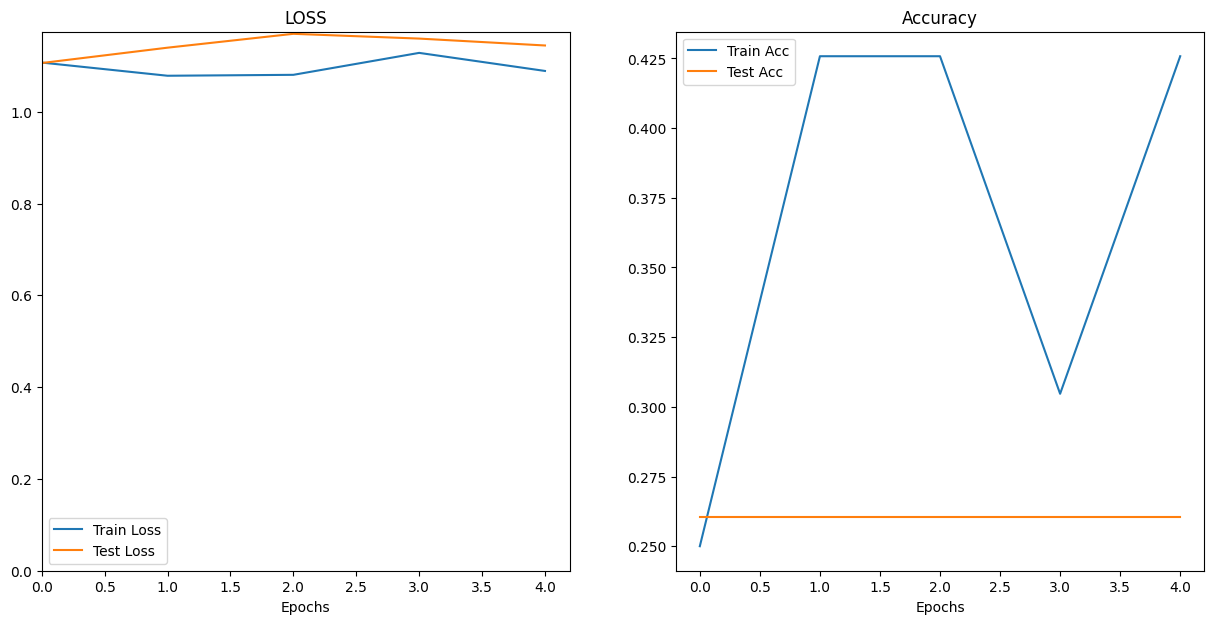

In [ ]:
plot_loss_curves(model_0_results)

We want idely that our training loss reduce as much as test loss.

The Loss Curve Above show underfitting,and is also Performing poorly on test loss

In [ ]:
model_0_results

{'train_loss': [1.1071179807186127,
  1.0784028097987175,
  1.0804155096411705,
  1.1282186210155487,
  1.0888646095991135],
 'train_acc': [0.25, 0.42578125, 0.42578125, 0.3046875, 0.42578125],
 'test_loss': [1.1061032613118489,
  1.1395694017410278,
  1.1697556575139363,
  1.1593709389368694,
  1.1443432172139485],
 'test_acc': [0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667]}

#Overfitting and Underfitting

## Dealing with Overfitting



*   Get More Data
*   Data Augmentation

*   Better Data
*   Use Transfer Learning


*   Simplify Your Model ( Less layers,hidden units )
*   Use Leraning rate decay
*   Use Early Stopping







## Dealing With Underfitting

* Add more layers
* Tweak the learning rate
* Train for longer
* Use Transfer Learning
* Use less regularization

# Model 1: Data Augmentation

Some Model with Data Augmenation

##9.1 Create Transform with Data Augmentaion

In [ ]:
# Create Train Transform with Trivial

train_transform_trivial=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.TrivialAugmentWide(num_magnitude_bins=31),
    transforms.ToTensor()
])

test_transform_simple=transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

## 9.2 Create train and test Dataset and Dataloader

In [ ]:
# Turn Image Folder into Dataset
train_data_augmented=datasets.ImageFolder(root=train_dir,
                                          transform=train_transform_trivial,
                                          )
test_data_simple=datasets.ImageFolder(root=test_dir,
                                      transform=test_transform_simple)

In [ ]:
from numpy._core.fromnumeric import shape
#  Turn DataLoaders into dataloaders
BATCH_SIZE=32
NUM_OF_WORKERS=os.cpu_count()
SEED=42

torch.manual_seed(SEED)

train_data_loader_augemnted=DataLoader(dataset=train_data_augmented,
                                      batch_size=BATCH_SIZE,
                                       shuffle=True,
                                       num_workers=NUM_OF_WORKERS)

test_data_loader_simple=DataLoader(dataset=test_data_simple,
                                      batch_size=BATCH_SIZE,
                                       shuffle=False,
                                       num_workers=NUM_OF_WORKERS)

## 9.3 Construct and Train Model 1



In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
model_1=TinyVGG(3,10,len(train_data_augmented.classes)).to(device)

# Train

EPOCH=5
accuracy_fn = Accuracy(task="multiclass", num_classes=len(train_data.classes)).to(device)
loss_fn=torch.nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(params=model_1.parameters(),lr=0.001)

from timeit import default_timer as timer
start_time=timer()

# Train Loop
model_1_results=train_loop(model_1,train_data_loader_augemnted,
                           test_data_loader_simple,
                           loss_fn,optimizer,
                           accuracy_fn,
                           EPOCH
                          )
end_time=timer()
total_time_model_1=end_time-start_time
model_1_results
print(f'Total Time Taken: {total_time_model_1:.4f}')

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train Loss 1.1070 | Train Accuracy 0.2578 | Test Loss 1.1383  Test Accuracy 0.2604
Epoch: 1 | Train Loss 1.0827 | Train Accuracy 0.4258 | Test Loss 1.1681  Test Accuracy 0.1979
Epoch: 2 | Train Loss 1.1221 | Train Accuracy 0.2930 | Test Loss 1.1740  Test Accuracy 0.1979
Epoch: 3 | Train Loss 1.0955 | Train Accuracy 0.4141 | Test Loss 1.1427  Test Accuracy 0.2083
Epoch: 4 | Train Loss 1.0946 | Train Accuracy 0.3047 | Test Loss 1.1419  Test Accuracy 0.2188
Total Time Taken: 22.8884


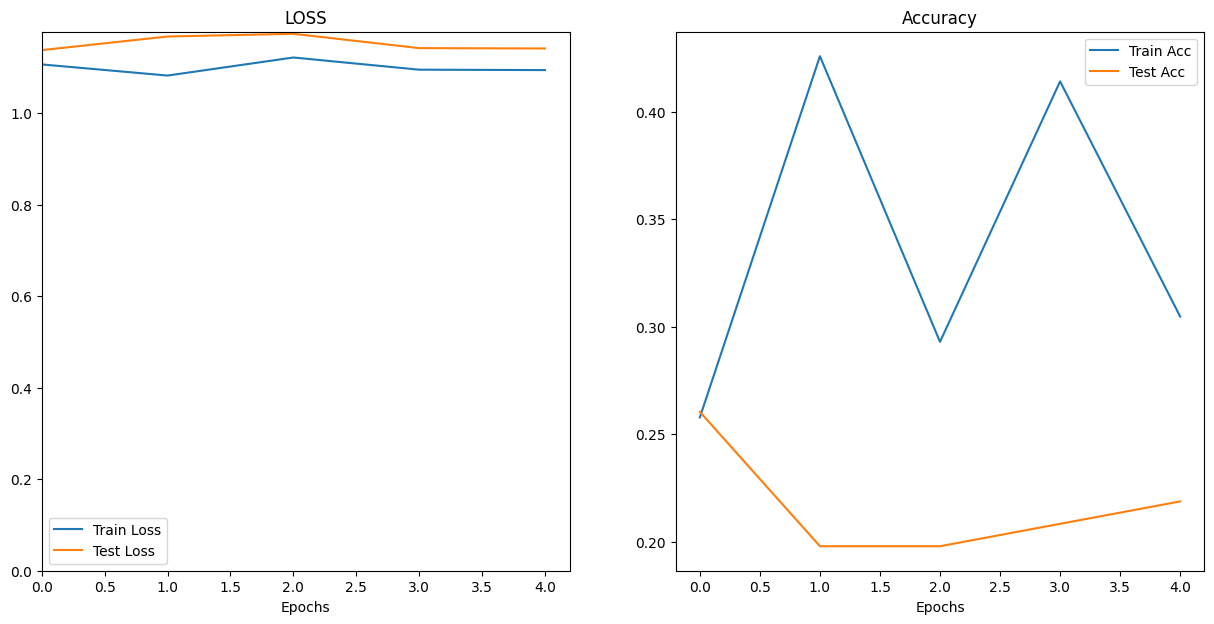

In [ ]:
plot_loss_curves(model_1_results)

# Compare Model Results

In [ ]:
import pandas as pd

model_0_df=pd.DataFrame(model_0_results)
model_1_df=pd.DataFrame(model_1_results)
model_1_df

,train_loss,train_acc,test_loss,test_acc
0,1.107008,0.257812,1.138306,0.260417
1,1.082676,0.425781,1.168054,0.197917
2,1.122148,0.292969,1.173952,0.197917
3,1.095519,0.414062,1.142690,0.208333
4,1.094643,0.304688,1.141870,0.218750


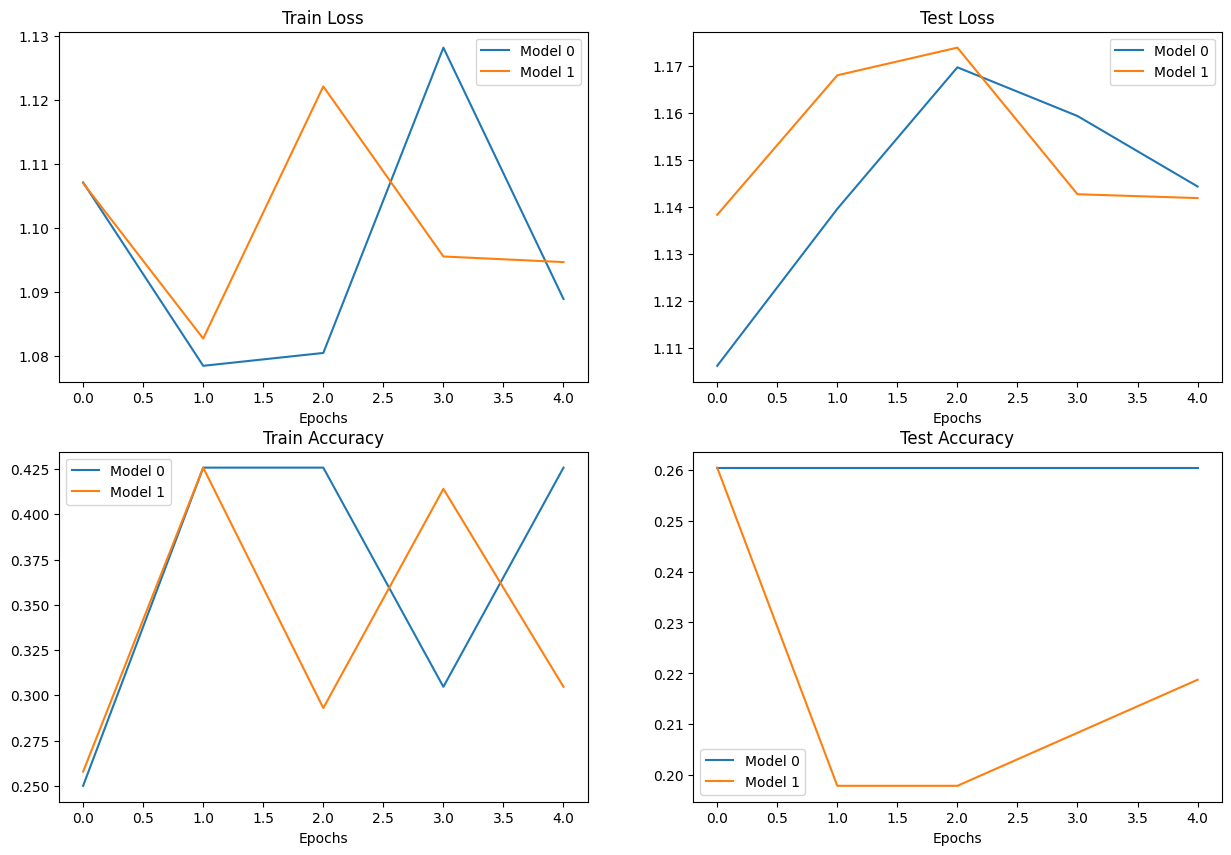

In [ ]:
#Set up a plot

plt.figure(figsize=(15,10))

epochs=range(len(model_0_df))

#Plot  the train loss

plt.subplot(2,2,1)
plt.plot(epochs,model_0_df['train_loss'],label='Model 0')
plt.plot(epochs,model_1_df['train_loss'],label='Model 1')
plt.xlabel('Epochs')
plt.title('Train Loss')
plt.legend()

#Plot  the test loss

plt.subplot(2,2,2)
plt.plot(epochs,model_0_df['test_loss'],label='Model 0')
plt.plot(epochs,model_1_df['test_loss'],label='Model 1')
plt.xlabel('Epochs')
plt.title('Test Loss')
plt.legend()

#Plot the train Accuracu

plt.subplot(2,2,3)
plt.plot(epochs,model_0_df['train_acc'],label='Model 0')
plt.plot(epochs,model_1_df['train_acc'],label='Model 1')
plt.xlabel('Epochs')
plt.title('Train Accuracy')
plt.legend()

#Plot  the test Accuracy

plt.subplot(2,2,4)
plt.plot(epochs,model_0_df['test_acc'],label='Model 0')
plt.plot(epochs,model_1_df['test_acc'],label='Model 1')
plt.xlabel('Epochs')
plt.title('Test Accuracy')
plt.legend()


# Making Prediction on a Custom Image that is not in either Training or Testing data

In [ ]:
import requests
custom_image_path=data_path/'custom_pizza.jpeg'

# Download the image if doesnt exist.
if custom_image_path.is_file():
  print("FOUND")
else:
  with open(custom_image_path,'wb') as f:
    #Download from google
    request=requests.get('https://pkgiftshop.com/user_files/product_images/1670525661-ClLbsG.png')
    f.write(request.content)
    print("Downloaded")



Downloaded


## Predicting on Custom DataSet

In [ ]:
import torchvision

#Read custom Image
custom_img_uint8=torchvision.io.read_image(custom_image_path)
custom_img_uint8.shape


torch.Size([3, 600, 600])

Output Type (torch.uint8): The resulting tensor (custom_img_uint8) stores pixel values as 8-bit unsigned integers, meaning pixel values range from 0 to 255

Shape is torch.Size([3, 600, 600])
Datatype is torch.uint8


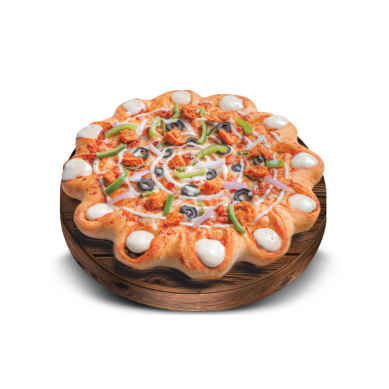

In [ ]:
#custom_img_uint8=custom_img_uint8.permute(1,2,0)
plt.imshow(custom_img_uint8.permute(1,2,0))
plt.axis(False)

# Get Meta data
print(f'Shape is {custom_img_uint8.shape}')
print(f"Datatype is {custom_img_uint8.dtype}")



1.  Should be tensor with float32
2.   Shape (64,64)
3.   On the right Device



In [ ]:
# try to make a prediction on image with diff dtype and shape

model_1.eval()
with torch.inference_mode():
  '''will throw type mismatch or shape error'''
  # y=model_1(custom_img_uint8).to(device)

In [ ]:
#load the custom image and convert into float32
custom_image=custom_img_uint8.type(torch.float32)/255.0
custom_image=custom_image.to(device)

print(custom_image.shape)
model_1
with torch.inference_mode():
  '''Cant be Multiplied error'''
  #y=model_1(custom_image).to(device)


torch.Size([600, 600, 3])


torch.Size([3, 64, 64])

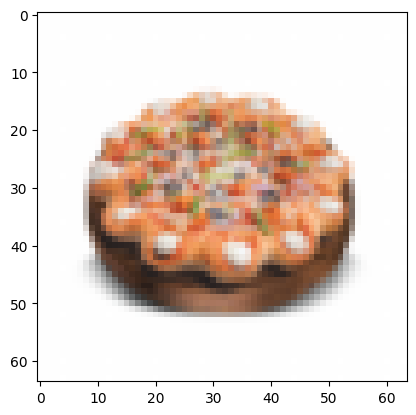

In [ ]:
# Lets Create Transform Looop to Resize

custom_img_transform=transforms.Compose([
    transforms.Resize(size=(64,64))

])

custom_image.shape
# Transform target image
custom_image_transformed=custom_img_transform(custom_image)

plt.imshow(custom_image_transformed.permute(1,2,0))
custom_image_transformed.shape


In [ ]:
print(f'Original shape: {custom_image.shape}')
print(f'Transformed shape: {custom_image_transformed.shape}')

Original shape: torch.Size([3, 600, 600])
Transformed shape: torch.Size([3, 64, 64])


In [ ]:
'''This will Error CZ no Batch Size'''

# model_1.eval()
# with torch.inference_mode():
#   y=model_1(custom_image_transformed)

'This will Error CZ no Batch Size'

In [ ]:
model_1.eval()
with torch.inference_mode():
  custom_image_pred=torch.softmax(model_1(custom_image_transformed.unsqueeze(0)),dim=1) # Raw logits
  custom_image_pred_labels=torch.argmax(custom_image_pred)
print(custom_image_pred)
print(custom_image_pred_labels)
class_names[custom_image_pred_labels]


tensor([[0.3563, 0.3567, 0.2870]])
tensor(1)


'steak'

# Functionize Custom Image Prediction

In [ ]:
def custom_image_pred_and_plot(model:torch.nn.Module,
                               image_path:str,
                               class_names:List[str]=None,
                               transform=None,
                               device=device):
  '''Make Prediction on Traget Image with Pretrained Model'''

  #1. Load Image and Change Type
  target_image=torchvision.io.read_image(str(image_path)).type(torch.float32)

  #2. Divide the Image by 255 to normalize
  target_image=target_image/255

  #3. Transform
  if transform:
    target_image=transform(target_image)

  #4. Device Dignostic
  model=model.to(device)
  target_image=target_image.to(device)

  #5. Make Prediction
  model.eval()
  with torch.inference_mode():

    # Add batch dimension
    target_image=target_image.unsqueeze(0)

    target_image_pred=torch.softmax(model(target_image).to(device),dim=1)

    target_image_pred_prob=torch.argmax(target_image_pred,dim=1)

    # Convert to Label
    target_image_pred_label=class_names[target_image_pred_prob]

    #Plot the image alongside the prediction and Prob
    plt.imshow(target_image.squeeze(0).permute(1,2,0))
    if class_names:
      title=f'Prediction :{target_image_pred_label} | Probability {target_image_pred.max():.3f} '
    else:
      title=f'Pred Prob {target_image_pred_prob}'
    plt.title(title)
    plt.axis(False)






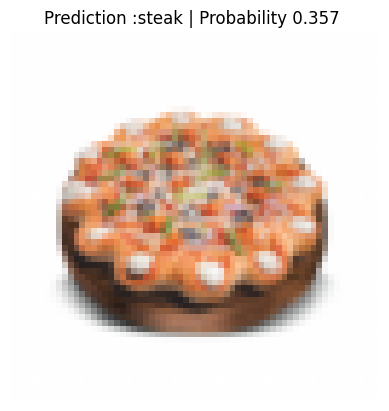

In [ ]:
custom_image_pred_and_plot(model_1
                           ,custom_image_path,
                           class_names,
                           custom_img_transform)

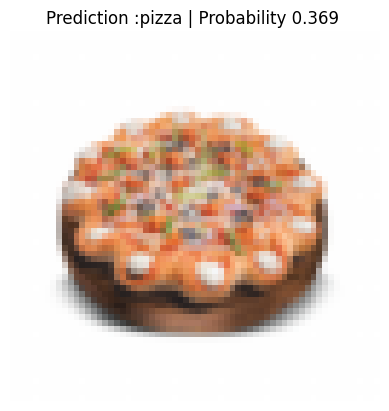

In [ ]:
custom_image_pred_and_plot(model_0
                           ,custom_image_path,
                           class_names,
                           custom_img_transform)